# Imports

In [1]:
import numpy as np
import sympy as sp
from numba import njit

Mis funciones definidas en `/code/src/`

In [2]:
import sys
import os

# Navigate up to the 'code' directory, then into 'src'
sys.path.append(os.path.abspath('../src'))

# Import the functions
from dynamics import generate_orbit, generate_escape_time_fractal, generate_fatou_basins, make_generate_orbit_jitted, make_generate_escape_time_fractal_jitted, make_generate_fatou_basins_jitted
from utils import DynamicsPlotter

# Ejemplo del libro ($z \mapsto z^2 - 1$)

Defino la función $z \mapsto z^2 - 1$ y una función de python precompilada para obtener los tiempos de escape de cada punto en una región del plano según la función $z \mapsto z^2 - 1$.

In [3]:
@njit
def R2m1(z):
    return z**2 - 1


generate_escape_time_fractal_for_R2m1 = make_generate_escape_time_fractal_jitted(R2m1)
generate_fatou_basins_for_R2m1 = make_generate_fatou_basins_jitted(R2m1)

Calculo los tiempos de escape.

In [4]:
max_distance_to_origin = 2

xmin = -max_distance_to_origin
xmax = max_distance_to_origin
ymin = -max_distance_to_origin
ymax = max_distance_to_origin

horizontal_pixels = 1000
vertical_pixels = 1000

max_iter = 100

escape_times = generate_escape_time_fractal_for_R2m1(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, max_iter=max_iter, escape_radius=(1+np.sqrt(5))/2)

Dibujo el conjunto de Julia.

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Julia Set for $z^2 - 1$'}>)

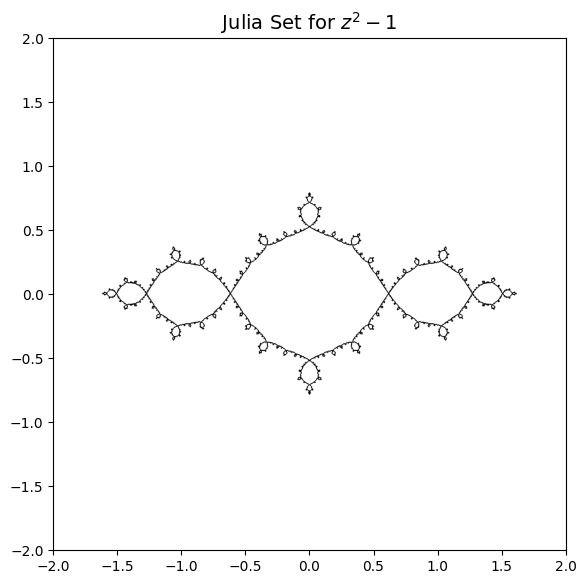

In [5]:
plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

plotter.plot_julia_set_from_escape_times(escape_times, max_iter=max_iter, title=r"Julia Set for $z^2 - 1$")

Marco los puntos fijos y el extremo de $F_{-1}$.

<Axes: title={'center': 'Julia Set for $z^2 - 1$'}>

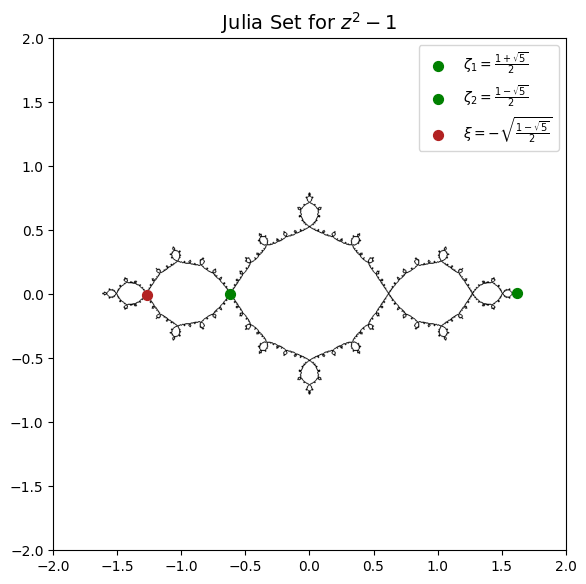

In [6]:
zeta1 = (1+np.sqrt(5))/2 + 1e-2j # La parte imaginaria es para que quede mejor en la visualización
zeta2 = (1-np.sqrt(5))/2
chi = -np.sqrt(zeta1)

fig, ax = plotter.plot_julia_set_from_escape_times(escape_times, max_iter=100, title=r"Julia Set for $z^2 - 1$")
plotter.add_points(ax, [zeta1], label=r"$\zeta_1 = \frac{1 + \sqrt{5}}{2}$", marker="o", color='green', s=50)
plotter.add_points(ax, [zeta2], label=r"$\zeta_2 = \frac{1 - \sqrt{5}}{2}$", marker="o", color='green', s=50)
plotter.add_points(ax, [chi], label=r"$\xi = -\sqrt{\frac{1 - \sqrt{5}}{2}}$", marker="o", color='firebrick', s=50)

Marco los $-1$ y $0$ que forman un 2-ciclo atractor.

<Axes: title={'center': 'Julia Set for $z^2 - 1$'}>

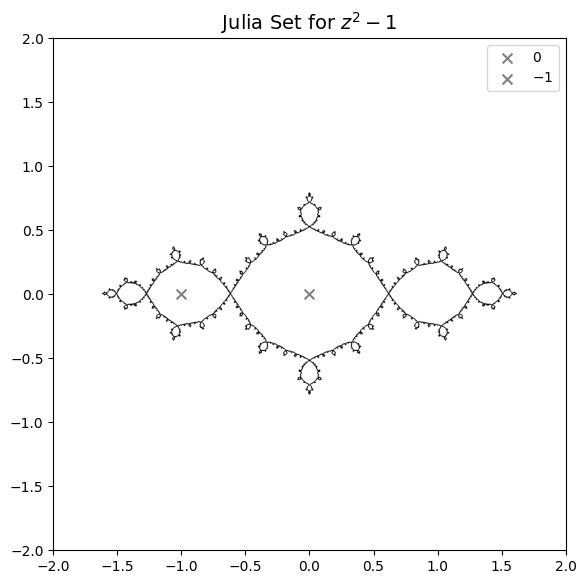

In [7]:
attractor1 = 0
attractor2 = -1

fig1, ax1 = plotter.plot_julia_set_from_escape_times(escape_times, max_iter=100, title=r"Julia Set for $z^2 - 1$")
plotter.add_points(ax1, [attractor1], label=r"$0$", marker="x", color='gray', s=50)
plotter.add_points(ax1, [attractor2], label=r"$-1$", marker="x", color='gray', s=50)

Muestro las componentes alternas que van acaban en $F_{-1}$ y $F_0$ alternando de una a otra.

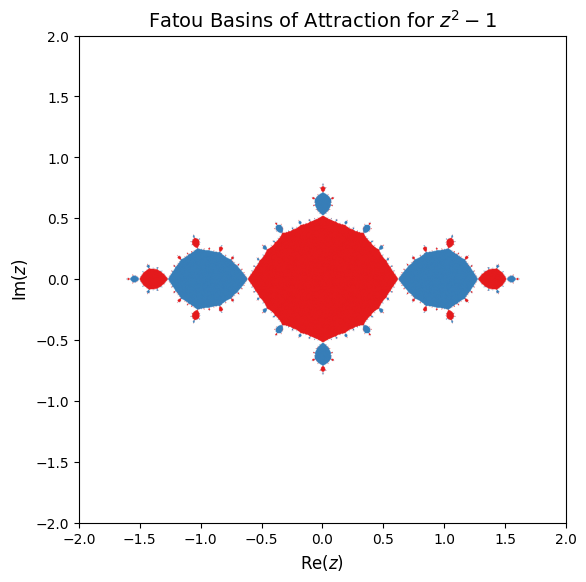

In [8]:
attractors = [attractor1, attractor2]

basins = generate_fatou_basins_for_R2m1(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=1e-6)

fig2, ax2 = plotter.plot_fatou_basins(basins, title="Fatou Basins of Attraction for $z^2 - 1$")